In [1]:
import pandas as pd
import torch
import numpy as np
import pickle as pkl

In [2]:
diatoms = pd.read_csv('DiatomInventories_GTstudentproject.csv', sep=';')
ibd = pd.read_csv('IBD_GTstudentproject.csv', sep=';')
ibd.head()

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S05155230_20070803,"13,7","0,7426900584795321",Moderate
1,S02003100_20070906,"13,7","0,7426900584795321",Moderate
2,S05058935_20070905,"14,7","0,8011695906432748",Good
3,S02046400_20070804,"10,5","0,5555555555555555",Moderate
4,S02120000_20070801,"12,1","0,6768292682926830",Moderate


In [3]:
with open('taxon_to_onehot.txt', 'rb') as f:
    taxons = f.readlines()
    taxons = [x.decode('utf-8').strip() for x in taxons]
diatoms['onehot'] = diatoms['TaxonCode'].apply(lambda x: taxons.index(x))

In [4]:
diatoms_per_sampling_operation = pkl.load(open('diatoms_per_sampling_operation.pkl', 'rb'))

In [5]:
ibd_per_sampling_operation = ibd.drop_duplicates(subset=['SamplingOperations_code'])
ibd_per_sampling_operation = ibd_per_sampling_operation.set_index('SamplingOperations_code').to_dict(orient='index')

In [ ]:
y_map = {"High": 0, "Good": 1, "Moderate": 2, "Poor": 3, "Bad": 4, "Unassessed": -1}

In [20]:
sampling_op_to_tensor_ibd = {}
for key in diatoms_per_sampling_operation:
    scaled_onehot = torch.zeros((diatoms['onehot'].max() + 1))
    one_hot = torch.zeros((diatoms['onehot'].max() + 1))
    scaled_onehot[diatoms_per_sampling_operation[key]['onehot'].to_list()] = torch.tensor(diatoms_per_sampling_operation[key]['Abundance_pm'].to_list())
    one_hot[diatoms_per_sampling_operation[key]['onehot'].to_list()] = 1
    try:
        ibd_status = y_map.get(ibd_per_sampling_operation[key]['IBD_EQR_Status'], -1) 
        sampling_op_to_tensor_ibd[key] = (scaled_onehot, one_hot, torch.tensor([ibd_status]))
    except KeyError:
        # print(f"Key {key} not found in IBD dataset. Skipping this sampling operation.")
        continue

# Save the updated tensor mapping
with open('sampling_op_to_tensor_ibd.pkl', 'wb') as f:
    pkl.dump(sampling_op_to_tensor_ibd, f)


In [21]:
print(f"Number of sampling operations successfully processed: {len(sampling_op_to_tensor_ibd)}")

Number of sampling operations successfully processed: 48636


In [23]:
sampling_op_to_tensor = pkl.load(open('sampling_op_to_tensor_ibd.pkl', 'rb'))
from torch.utils.data import Dataset, DataLoader

class DiatomDataset(Dataset):
    def __init__(self, sampling_op_to_tensor, x='scaled_onehot', y='IBD_EQR_Status'):
        self.sampling_op_to_tensor = sampling_op_to_tensor.copy()
        self.keys = list(self.sampling_op_to_tensor.keys())
        self.x = 0 if x == 'scaled_onehot' else 1
        self.y = 0  
        
        temp = []
        for key in self.keys:
            if self.sampling_op_to_tensor[key][2].item() == -1:  
                continue
            temp.append(key)
        
        print('Skipped', len(self.keys) - len(temp), 'samples')
        self.keys = temp

    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        return self.sampling_op_to_tensor[key][self.x], self.sampling_op_to_tensor[key][2].item() 

In [32]:
class DiatomDatasetBinary(Dataset):
    def __init__(self, sampling_op_to_tensor, x='scaled_onehot', y='IBD_EQR_Status'):
        self.sampling_op_to_tensor = sampling_op_to_tensor.copy()
        self.keys = list(self.sampling_op_to_tensor.keys())
        self.x = 0 if x == 'scaled_onehot' else 1
        self.y = 0 if y == 'IBD_EQR_Status' else 1
        
        temp = []
        for key in self.keys:
            if self.sampling_op_to_tensor[key][2].item() == -1:
                continue
            else:
                temp.append(key)
        
                updated_tuple = (
                    self.sampling_op_to_tensor[key][0],
                    self.sampling_op_to_tensor[key][1],
                    torch.tensor([1 if self.sampling_op_to_tensor[key][2].item() >= 2 else 0])
                )
                self.sampling_op_to_tensor[key] = updated_tuple
        
        
        print('Skipped', len(self.keys) - len(temp), 'samples')
        self.keys = temp

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]
        return self.sampling_op_to_tensor[key][self.x], self.sampling_op_to_tensor[key][2].item(), key


In [25]:
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

class Net(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim_1, hidden_dim_2, hidden_dim_3):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim_1)
        self.fc2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.fc3 = nn.Linear(hidden_dim_2, hidden_dim_3)
        self.fc4 = nn.Linear(hidden_dim_3, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)         
        return x

In [33]:
dataset_ibd = DiatomDatasetBinary(sampling_op_to_tensor_ibd, x='scaled_onehot', y='IBD_EQR_Status')

train_size = int(0.8 * len(dataset_ibd))
test_size = len(dataset_ibd) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset_ibd, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

input_dim = diatoms['onehot'].max() + 1
output_dim = 2  

model = Net(input_dim, output_dim, 4096, 1024, 256)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    correct = 0
    total = 0
    for i, data in enumerate(tqdm(train_dataloader)):
        x, y,_ = data
        optimizer.zero_grad()
        output = model(x.float())
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(output.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    print(f'Epoch {epoch}, Loss {loss.item()}, Accuracy {100 * correct / total}')

print('Finished Training')

Skipped 0 samples


100%|██████████| 1216/1216 [00:27<00:00, 44.89it/s]


Epoch 0, Loss 0.18584702908992767, Accuracy 90.09715225660533


100%|██████████| 1216/1216 [00:26<00:00, 45.44it/s]


Epoch 1, Loss 0.1775321513414383, Accuracy 91.90397861622289


...

Epoch 7, Loss 0.021270615980029106, Accuracy 96.02909427367122


100%|██████████| 1216/1216 [00:26<00:00, 45.24it/s]


Epoch 8, Loss 0.0697849839925766, Accuracy 96.49172406702992


100%|██████████| 1216/1216 [00:28<00:00, 43.24it/s]

Epoch 9, Loss 0.033097777515649796, Accuracy 96.85668757067955
Finished Training


100%|██████████| 304/304 [00:01<00:00, 243.39it/s]


Final Test Accuracy 80.87993421052632


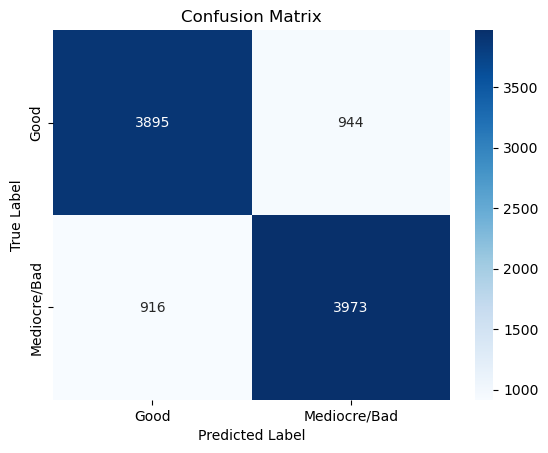

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
correct = 0
total = 0
predictions = []
true_classes = []
for i, data in enumerate(tqdm(test_dataloader)):
    x, y, keys = data
    output = model(x.float())
    _, predicted = torch.max(output.data, 1)
    predictions.extend(predicted)
    true_classes.extend(y)
    total += y.size(0)
    correct += (predicted == y).sum().item()
print(f'Final Test Accuracy {100 * correct / total}')
conf_matrix = confusion_matrix(true_classes, predictions)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
           xticklabels=['Good', 'Mediocre/Bad'],
            yticklabels=['Good', 'Mediocre/Bad'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()